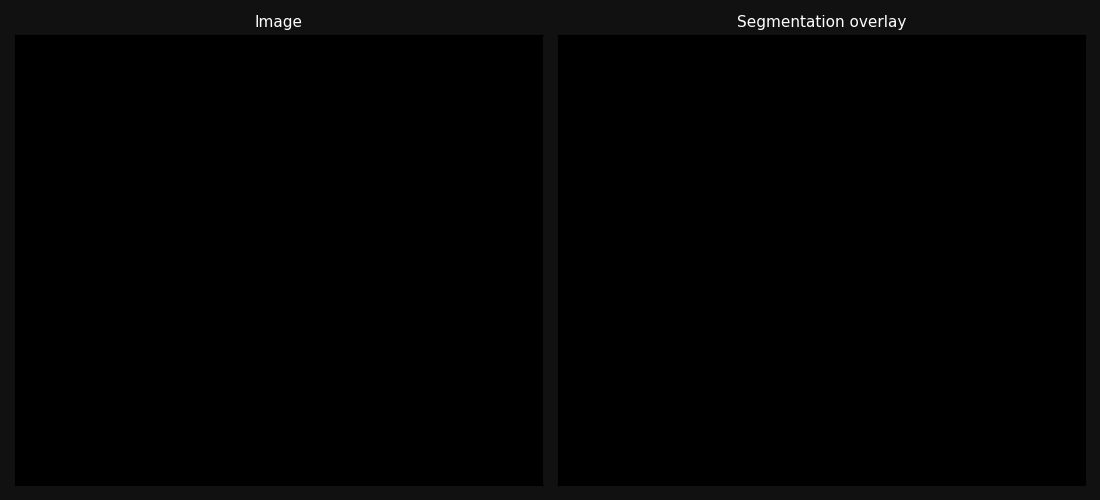

In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import csv
import ipywidgets as w
from IPython.display import display
%matplotlib widget

BASE_DIR = "/users/project1/pt01190/sjs/Segmentacja_MK080-MK089"

SEQUENCE_MAP = {
    "T1_TSE":      ("T1_TSE_Segmentation-label.nii.gz",     "3 t1_tse_tra_HR_3mm.nii.gz"),
    "T2_DIXON_IN": ("T2_DIXON_IN_Segmentation-label.nii.gz","4 t2_tse_dixon_tra_HR_3mm_in.nii.gz"),
    "T2_DIXON_F":  ("T2_DIXON_F_Segmentation-label.nii.gz", "5 t2_tse_dixon_tra_HR_3mm_F.nii.gz"),
    "T2_DIXON_W":  ("T2_DIXON_W_Segmentation-label.nii.gz", "6 t2_tse_dixon_tra_HR_3mm_W.nii.gz"),
    "ADC":         ("ADC_Segmentation-label.nii.gz",         "8 ep2d_diff_b_0_10_20_30_50_80_100_300_400_50_8DS3.nii.gz"),
    "T1_VIBE_IN":  ("T1_VIBE_IN_Segmentation-label.nii.gz", "9 t1_vibe_dixon_tra_iso_in.nii.gz"),
    "T1_VIBE_F":   ("T1_VIBE_F_Segmentation-label.nii.gz",  "10 t1_vibe_dixon_tra_iso_F.nii.gz"),
    "T1_VIBE_W":   ("T1_VIBE_W_Segmentation-label.nii.gz",  "11 t1_vibe_dixon_tra_iso_W.nii.gz"),
    "T2_SPACE":    ("T2_SPACE_Segmentation-label.nii.gz",    "12 t2_space_tra_iso_1.0mm.nii.gz"),
    "Sialo_MR":    ("Sialo_MR_Segmentation-label.nii.gz",    "13 Sialo-MR_t2_space_tra_08mm.nii.gz"),
}

def get_patients():
    dirs = sorted(glob.glob(os.path.join(BASE_DIR, "*_Segmentacja*")))
    return [os.path.basename(d) for d in dirs if os.path.isdir(d)]

def find_file(folder, filename):
    p = os.path.join(folder, filename)
    if os.path.exists(p):
        return p
    matches = glob.glob(os.path.join(folder, f"*{filename.split(' ', 1)[-1]}*"))
    return matches[0] if matches else None

def load_colortable(csv_path):
    colors = {0: (0, 0, 0, 0)}
    if not os.path.exists(csv_path):
        return colors
    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                label = int(row.get('LabelValue') or row.get('label') or list(row.values())[0])
                r = int(row.get('R') or row.get('r') or 128) / 255
                g = int(row.get('G') or row.get('g') or 128) / 255
                b = int(row.get('B') or row.get('b') or 128) / 255
                a = int(row.get('A') or row.get('a') or 255) / 255
                colors[label] = (r, g, b, a)
            except Exception:
                pass
    return colors

def make_label_cmap(seg_data, color_dict):
    max_label = int(seg_data.max())
    cmap_colors = [color_dict.get(i, (1, 0, 1, 0.6)) for i in range(max_label + 1)]
    return mcolors.ListedColormap(cmap_colors), max_label

class SegViewer:
    def __init__(self):
        self.patients = get_patients()
        if not self.patients:
            raise RuntimeError(f"No patient folders found under: {BASE_DIR}")

        self.img_data = None
        self.seg_data = None
        self.cmap_seg = None

        # --- widgets ---
        self.dd_patient  = w.Dropdown(options=self.patients,
                                      description='Patient:',
                                      layout=w.Layout(width='260px'))
        self.dd_sequence = w.Dropdown(options=list(SEQUENCE_MAP.keys()),
                                      description='Sequence:',
                                      layout=w.Layout(width='260px'))
        self.sl_slice    = w.IntSlider(value=0, min=0, max=1, step=1,
                                       description='Slice:',
                                       continuous_update=True,
                                       layout=w.Layout(width='480px'))
        self.lbl_warn    = w.Label(value='', style={'description_width': '0px'})

        # --- persistent figure ---
        self.fig, self.axes = plt.subplots(1, 2, figsize=(11, 5))
        self.fig.patch.set_facecolor('#111')
        for ax in self.axes:
            ax.set_facecolor('black')
            ax.set_xticks([]); ax.set_yticks([])

        blank = np.zeros((10, 10))
        self.im_img = self.axes[0].imshow(blank, cmap='gray', aspect='auto', animated=True)
        self.im_bg  = self.axes[1].imshow(blank, cmap='gray', aspect='auto',
                                          alpha=0.2, animated=True)
        self.im_seg = self.axes[1].imshow(blank, cmap='gray', aspect='auto',
                                          alpha=1, animated=True)
        self.axes[0].set_title('Image', color='white', fontsize=11)
        self.axes[1].set_title('Segmentation overlay', color='white', fontsize=11)
        self.fig.tight_layout()

        # --- connect ---
        self.dd_patient.observe(self._on_source_change, names='value')
        self.dd_sequence.observe(self._on_source_change, names='value')
        self.sl_slice.observe(self._on_slice, names='value')

        # --- layout & display ---
        controls = w.VBox([
            w.HBox([self.dd_patient, self.dd_sequence]),
            self.sl_slice,
            self.lbl_warn,
        ])
        display(controls)
        plt.show()

        self._load_volume()

    def _load_volume(self):
        patient  = self.dd_patient.value
        sequence = self.dd_sequence.value
        folder   = os.path.join(BASE_DIR, patient)
        seg_fname, img_fname = SEQUENCE_MAP[sequence]

        img_path = find_file(folder, img_fname)
        seg_path = find_file(folder, seg_fname)
        warnings = []

        self.img_data = nib.load(img_path).get_fdata() if img_path else None
        if not img_path:
            warnings.append(f"image not found")

        self.seg_data = None
        self.cmap_seg = None
        if seg_path:
            self.seg_data = np.round(nib.load(seg_path).get_fdata()).astype(int)
            ct_path = os.path.join(folder, seg_fname.replace('-label.nii.gz', '_ColorTable.csv'))
            self.cmap_seg, _ = make_label_cmap(self.seg_data, load_colortable(ct_path))
        else:
            warnings.append(f"no segmentation for {sequence}")

        ref = self.seg_data if self.seg_data is not None else self.img_data
        if ref is not None:
            n = ref.shape[2]
            self.sl_slice.max = n - 1
            self.sl_slice.value = min(self.sl_slice.value, n - 1)

        self.lbl_warn.value = '⚠ ' + ' | '.join(warnings) if warnings else ''
        self._update_display()

    def _on_source_change(self, change):
        self._load_volume()

    def _on_slice(self, change):
        self._update_display()

    def _update_display(self):
        sl = self.sl_slice.value

        if self.img_data is not None:
            slc = np.rot90(self.img_data[:, :, sl])
            self.im_img.set_data(slc)
            self.im_img.set_clim(slc.min(), slc.max())
            self.im_bg.set_data(slc)
            self.im_bg.set_clim(slc.min(), slc.max())
        
        if self.seg_data is not None:
            seg_slc = np.rot90(self.seg_data[:, :, sl]).astype(float)
            masked = np.ma.masked_where(seg_slc == 0, seg_slc)
            self.im_seg.set_data(masked)
            self.im_seg.set_cmap(self.cmap_seg)
            self.im_seg.set_clim(0, self.cmap_seg.N - 1)
            self.im_seg.set_alpha(0.55)
        else:
            self.im_seg.set_alpha(0)

        self.fig.canvas.draw_idle()

SegViewer()